# Project Review 2 - Code for implementation as per methodology

Team members:
- Surya M S
- Vasundhradevi R
- Guru Prasaath M

# Gold Price Volatality & Regime Analysis
# Structural Regime-Based Tail Evolution Testing
## Updated comparative workflow: EWMA–Historical VaR vs Markov-Switching–EVT

This notebook reads the attached gold price dataset, detects variance regimes, compares two risk-model combinations, exports result tables/plots, and writes files used by the Streamlit dashboard.

## 1. Imports and configuration

In [1]:

from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto
from scipy.optimize import minimize
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

BASE_DIR = Path("./")
DATA_PATH = BASE_DIR / "goldprices.csv"
RESULT_DIR = BASE_DIR / "gold_results"
FIG_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.01
LAMBDA = 0.94
MIN_SEG_LEN = 200
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


ModuleNotFoundError: No module named 'matplotlib'

## 2. Load data and inspect columns

In [ ]:

df_raw = pd.read_csv(DATA_PATH)
print("Columns:", list(df_raw.columns))
df_raw.head()


Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20', 'Year', 'Month', 'Day_of_Week', 'Quarter']


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.949997,107.000000,106.260002,106.610001,8098700,106.949997,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.050003,108.150002,107.529999,107.540001,10471800,108.050003,1.028524,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.089996,108.180000,107.349998,107.919998,6656000,108.089996,0.037014,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.250000,109.580002,107.900002,107.910004,15785200,109.250000,1.073183,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.570000,110.699997,109.919998,110.449997,13213700,110.570000,1.208238,NaN,NaN,NaN,NaN,2016,2,3,1


## 3. Cleaning and return construction

The notebook uses `Close` when available and falls back sensibly if the dataset changes.

In [ ]:

def pick_price_column(df: pd.DataFrame) -> str:
    preferred = ["Close", "Adj Close", "close", "adj_close"]
    for col in preferred:
        if col in df.columns:
            return col
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric price column found.")
    return numeric_cols[0]

price_col = pick_price_column(df_raw)
df = df_raw.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)
df = df[[c for c in df.columns if c in ["Date", price_col, "Open", "High", "Low", "Volume", "Adj Close"] or c not in []]].copy()
df.rename(columns={price_col: "Price"}, inplace=True)
df["log_return"] = np.log(df["Price"] / df["Price"].shift(1))
df = df.dropna(subset=["log_return"]).reset_index(drop=True)
df["sq_return"] = df["log_return"] ** 2
print(df[["Date", "Price", "log_return"]].head())
print(df[["Date", "Price", "log_return"]].tail())


        Date       Price  log_return
0 2016-02-01  108.050003    0.010233
1 2016-02-02  108.089996    0.000370
2 2016-02-03  109.250000    0.010675
3 2016-02-04  110.570000    0.012010
4 2016-02-05  112.320000    0.015703
           Date       Price  log_return
2505 2026-01-16  421.290009   -0.004831
2506 2026-01-20  437.230011    0.037138
2507 2026-01-21  443.600006    0.014464
2508 2026-01-22  451.790009    0.018294
2509 2026-01-23  458.000000    0.013652


## 4. Descriptive statistics and intuitive example calculation

In [ ]:

example = df.iloc[1:3][["Date", "Price"]].copy()
example["manual_log_return"] = np.log(example["Price"] / example["Price"].shift(1))
desc = pd.DataFrame({
    "metric": ["rows", "start_date", "end_date", "mean_return", "std_return", "skew", "kurtosis"],
    "value": [
        len(df),
        df["Date"].min().date(),
        df["Date"].max().date(),
        df["log_return"].mean(),
        df["log_return"].std(),
        df["log_return"].skew(),
        df["log_return"].kurtosis(),
    ]
})
desc


,metric,value
0,rows,2510
1,start_date,2016-02-01
2,end_date,2026-01-23
3,mean_return,0.000579
4,std_return,0.009378
5,skew,-0.253019
6,kurtosis,3.584593


## 5. Structural break detection on variance

A simple greedy segmentation is used on squared returns. It finds two breakpoints that reduce within-segment variance error the most while keeping each segment large enough to be meaningful.

In [ ]:

def segment_sse(x: np.ndarray) -> float:
    if len(x) == 0:
        return 0.0
    mu = np.mean(x)
    return float(np.sum((x - mu) ** 2))

def best_single_break(x: np.ndarray, min_seg_len: int = 100):
    n = len(x)
    best_idx, best_gain = None, -np.inf
    total_sse = segment_sse(x)
    for idx in range(min_seg_len, n - min_seg_len):
        gain = total_sse - (segment_sse(x[:idx]) + segment_sse(x[idx:]))
        if gain > best_gain:
            best_idx, best_gain = idx, gain
    return best_idx, best_gain

def greedy_two_breaks(x: np.ndarray, min_seg_len: int = 100):
    first_idx, _ = best_single_break(x, min_seg_len)
    segments = [(0, first_idx), (first_idx, len(x))]
    candidate_breaks = [first_idx]
    for _ in range(1):
        best_global = None
        best_global_gain = -np.inf
        for s, e in segments:
            if e - s < 2 * min_seg_len:
                continue
            idx_local, gain = best_single_break(x[s:e], min_seg_len)
            if idx_local is None:
                continue
            idx = s + idx_local
            if gain > best_global_gain:
                best_global_gain = gain
                best_global = idx
        if best_global is not None:
            candidate_breaks.append(best_global)
            candidate_breaks = sorted(candidate_breaks)
            segments = []
            prev = 0
            for bp in candidate_breaks:
                segments.append((prev, bp))
                prev = bp
            segments.append((prev, len(x)))
    return sorted(candidate_breaks), segments

breaks, segments = greedy_two_breaks(df["sq_return"].to_numpy(), MIN_SEG_LEN)
break_dates = [df.loc[i, "Date"] for i in breaks]
regime_rows = []
for i, (s, e) in enumerate(segments, start=1):
    regime_rows.append({
        "regime_id": i,
        "start_idx": s,
        "end_idx": e-1,
        "start_date": df.loc[s, "Date"],
        "end_date": df.loc[e-1, "Date"],
        "n_obs": e - s,
        "variance": df.loc[s:e-1, "log_return"].var()
    })
regime_table = pd.DataFrame(regime_rows)
regime_table


,regime_id,start_idx,end_idx,start_date,end_date,n_obs,variance
0,1,0,1020,2016-02-01,2020-02-20,1021,0.000057
1,2,1021,2307,2020-02-21,2025-04-03,1287,0.000096
2,3,2308,2509,2025-04-04,2026-01-23,202,0.000190


## 6. Regime labelling

The labels prioritize economic interpretation when the dates overlap the expected pandemic window.

In [ ]:

def assign_regime_label(start_date, end_date):
    if end_date < pd.Timestamp("2020-01-01"):
        return "Pre-Pandemic"
    if start_date <= pd.Timestamp("2021-12-31") and end_date >= pd.Timestamp("2020-01-01"):
        return "Pandemic Shock"
    return "Post-Pandemic"

regime_table["label"] = regime_table.apply(lambda r: assign_regime_label(r["start_date"], r["end_date"]), axis=1)
regime_table


,regime_id,start_idx,end_idx,start_date,end_date,n_obs,variance,label
0,1,0,1020,2016-02-01,2020-02-20,1021,0.000057,Pandemic Shock
1,2,1021,2307,2020-02-21,2025-04-03,1287,0.000096,Pandemic Shock
2,3,2308,2509,2025-04-04,2026-01-23,202,0.000190,Post-Pandemic


## 7. Visualize price, returns, and detected breaks

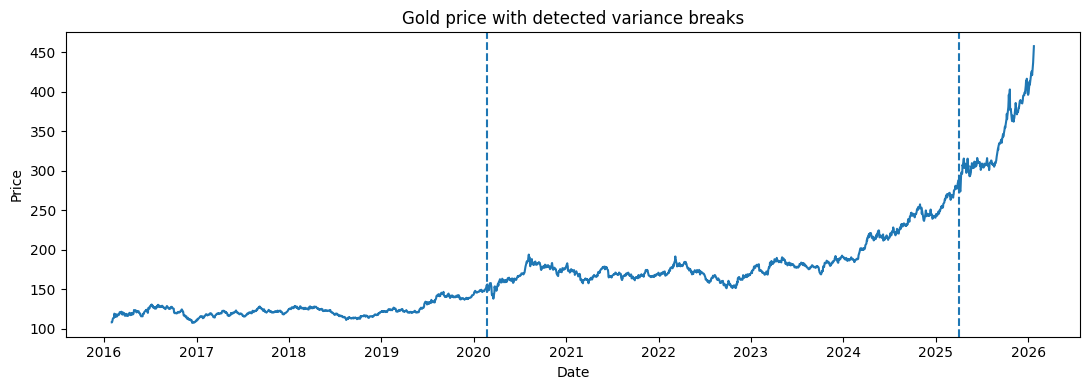

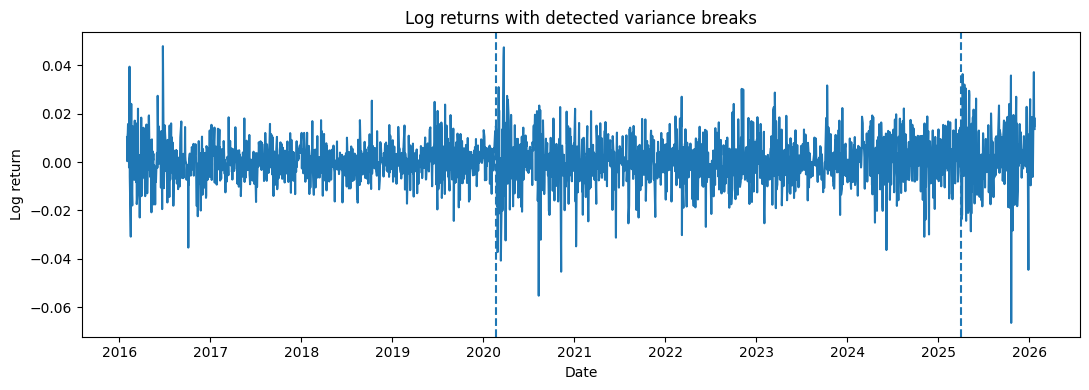

In [ ]:

fig = plt.figure(figsize=(11, 4))
plt.plot(df["Date"], df["Price"])
for d in break_dates:
    plt.axvline(d, linestyle='--')
plt.title("Gold price with detected variance breaks")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_price_with_breaks.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(11, 4))
plt.plot(df["Date"], df["log_return"])
for d in break_dates:
    plt.axvline(d, linestyle='--')
plt.title("Log returns with detected variance breaks")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_returns_with_breaks.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Model A — EWMA volatility with Historical Simulation VaR

This baseline is easy to explain: recent shocks get more weight and the VaR comes from the empirical return distribution.

In [ ]:

def ewma_volatility(returns: np.ndarray, lam: float = 0.94) -> np.ndarray:
    var = np.zeros_like(returns)
    var[0] = np.var(returns[:20]) if len(returns) >= 20 else np.var(returns)
    for t in range(1, len(returns)):
        var[t] = lam * var[t-1] + (1 - lam) * returns[t-1]**2
    return np.sqrt(np.maximum(var, 1e-12))

df["ewma_vol"] = ewma_volatility(df["log_return"].to_numpy(), LAMBDA)
window = 250 if len(df) > 300 else max(50, len(df)//4)
df["hs_var_1pct"] = df["log_return"].rolling(window).quantile(ALPHA)
df["ewma_hs_var"] = df["hs_var_1pct"]
df[["Date", "ewma_vol", "ewma_hs_var"]].tail()


,Date,ewma_vol,ewma_hs_var
2505,2026-01-16,0.013146,-0.028419
2506,2026-01-20,0.012800,-0.028419
2507,2026-01-21,0.015387,-0.028419
2508,2026-01-22,0.015333,-0.028419
2509,2026-01-23,0.015527,-0.028419


## 9. Model B — Markov-switching volatility with EVT tails

This model lets the return process move between hidden volatility states, then uses EVT only on the standardized residual extremes.

In [ ]:

endog = (df["log_return"] * 100).astype(float)
msm = MarkovRegression(endog, k_regimes=2, trend='c', switching_variance=True)
msm_res = msm.fit(em_iter=10, search_reps=10, search_iter=10, disp=False)

state_probs = msm_res.smoothed_marginal_probabilities
if isinstance(state_probs, pd.DataFrame):
    state_probs = state_probs.to_numpy()
state_var = np.asarray(msm_res.params[-2:])
state_sigma = np.sqrt(np.maximum(state_var, 1e-8)) / 100.0
state_mean = np.asarray(msm_res.params[:2]) / 100.0 if len(np.asarray(msm_res.params[:2])) == 2 else np.repeat(np.mean(df['log_return']), 2)
most_likely_state = state_probs.argmax(axis=1)
df["ms_state"] = most_likely_state
# conditional sigma and mean
cond_sigma = (state_probs * state_sigma.reshape(1, -1)).sum(axis=1)
cond_mu = (state_probs * state_mean.reshape(1, -1)).sum(axis=1)
df["ms_sigma"] = cond_sigma
df["ms_mu"] = cond_mu
df["ms_std_resid"] = (df["log_return"] - df["ms_mu"]) / df["ms_sigma"].replace(0, np.nan)
msm_res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Markov Switching Model Results                        
==============================================================================
Dep. Variable:             log_return   No. Observations:                 2510
Model:               MarkovRegression   Log Likelihood               -3233.309
Date:                Fri, 10 Apr 2026   AIC                           6478.618
Time:                        21:13:52   BIC                           6513.587
Sample:                             0   HQIC                          6491.311
                               - 2510                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0533      0.018      2.992      0.003       0.018       0.088
sigma2         0.5442      0.031     17.506      0.000       0.483       0.605
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0816      0.088      0.925      0.355      -0.091       0.255
sigma2         2.5852      0.340      7.612      0.000       1.920       3.251
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.9792      0.006    153.336      0.000       0.967       0.992
p[1->0]        0.1040      0.027      3.887      0.000       0.052       0.156
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

## 10. EVT fitting by regime and by tail

In [ ]:

def fit_gpd_tail(std_resid: pd.Series, tail: str = "left", q: float = 0.05):
    x = std_resid.dropna().to_numpy()
    if tail == "left":
        threshold = np.quantile(x, q)
        excess = threshold - x[x < threshold]
    else:
        threshold = np.quantile(x, 1-q)
        excess = x[x > threshold] - threshold
    if len(excess) < 20:
        return {"threshold": threshold, "shape": np.nan, "scale": np.nan, "n_exc": len(excess), "var_std": np.nan}
    c, loc, scale = genpareto.fit(excess, floc=0)
    p_exc = len(excess) / len(x)
    target_tail_prob = ALPHA
    if target_tail_prob >= p_exc:
        var_std = np.quantile(x, ALPHA if tail == 'left' else 1-ALPHA)
    else:
        q_excess = genpareto.ppf(target_tail_prob / p_exc, c, loc=0, scale=scale)
        var_std = threshold - q_excess if tail == 'left' else threshold + q_excess
    return {"threshold": threshold, "shape": c, "scale": scale, "n_exc": len(excess), "var_std": var_std}

def bootstrap_shape_ci(std_resid: pd.Series, tail: str = "left", q: float = 0.05, n_boot: int = 200):
    vals = std_resid.dropna().to_numpy()
    if len(vals) < 50:
        return (np.nan, np.nan)
    shapes = []
    for _ in range(n_boot):
        samp = pd.Series(np.random.choice(vals, size=len(vals), replace=True))
        res = fit_gpd_tail(samp, tail=tail, q=q)
        if np.isfinite(res["shape"]):
            shapes.append(res["shape"])
    if len(shapes) < 20:
        return (np.nan, np.nan)
    return tuple(np.quantile(shapes, [0.025, 0.975]))

regime_fit_rows = []
for _, r in regime_table.iterrows():
    seg = df[(df["Date"] >= r["start_date"]) & (df["Date"] <= r["end_date"])].copy()
    for tail in ["left", "right"]:
        fit = fit_gpd_tail(seg["ms_std_resid"], tail=tail, q=0.05)
        ci_lo, ci_hi = bootstrap_shape_ci(seg["ms_std_resid"], tail=tail, q=0.05, n_boot=150)
        regime_fit_rows.append({
            "label": r["label"],
            "tail": tail,
            "threshold": fit["threshold"],
            "shape_xi": fit["shape"],
            "shape_ci_low": ci_lo,
            "shape_ci_high": ci_hi,
            "scale_beta": fit["scale"],
            "n_exceedances": fit["n_exc"],
            "std_var_alpha": fit["var_std"],
        })
regime_tail_table = pd.DataFrame(regime_fit_rows)
regime_tail_table


,label,tail,threshold,shape_xi,shape_ci_low,shape_ci_high,scale_beta,n_exceedances,std_var_alpha
0,Pandemic Shock,left,-2.632845,-0.647204,-1.355591,-0.445434,0.597708,51,-2.757163
1,Pandemic Shock,right,0.546293,0.027484,-0.463739,0.237840,0.436680,51,0.644142
2,Pandemic Shock,left,-2.654610,-0.508562,-0.894213,-0.290646,0.453749,65,-2.749315
3,Pandemic Shock,right,0.865099,-0.034660,-0.504689,0.145656,0.402775,65,0.953631
4,Post-Pandemic,left,-2.219455,NaN,NaN,NaN,NaN,11,NaN
5,Post-Pandemic,right,1.549740,NaN,NaN,NaN,NaN,11,NaN


## 11. Build conditional EVT VaR series

In [ ]:

left_fit_all = fit_gpd_tail(df["ms_std_resid"], tail="left", q=0.05)
df["ms_evt_var"] = df["ms_mu"] + df["ms_sigma"] * left_fit_all["var_std"]

def breach_metrics(actual: pd.Series, var_series: pd.Series, alpha: float = 0.01):
    z = pd.DataFrame({"actual": actual, "var": var_series}).dropna().copy()
    z["breach"] = (z["actual"] < z["var"]).astype(int)
    breach_rate = z["breach"].mean()
    severity = (z.loc[z["breach"] == 1, "var"] - z.loc[z["breach"] == 1, "actual"]).mean() if z["breach"].sum() > 0 else 0.0
    consecutive = ((z["breach"].shift(1) == 1) & (z["breach"] == 1)).sum()
    clustering_ratio = consecutive / max(int(z["breach"].sum()), 1)
    qloss = np.mean((alpha - (z["actual"] < z["var"]).astype(int)) * (z["actual"] - z["var"]))
    return {"n": len(z), "breach_rate": breach_rate, "target_alpha": alpha, "avg_breach_severity": severity, "clustering_ratio": clustering_ratio, "quantile_loss": qloss}

comparison_rows = []
for model_name, col in [("EWMA + Historical VaR", "ewma_hs_var"), ("Markov Switching + EVT", "ms_evt_var")]:
    metrics = breach_metrics(df["log_return"], df[col], ALPHA)
    metrics["model"] = model_name
    comparison_rows.append(metrics)
model_comparison = pd.DataFrame(comparison_rows)[["model", "n", "breach_rate", "target_alpha", "avg_breach_severity", "clustering_ratio", "quantile_loss"]]
model_comparison


,model,n,breach_rate,target_alpha,avg_breach_severity,clustering_ratio,quantile_loss
0,EWMA + Historical VaR,2261,0.011942,0.01,0.006897,0.037037,0.000315
1,Markov Switching + EVT,2510,0.041036,0.01,0.002722,0.019417,0.000274


## 12. Regime-wise comparison table

In [ ]:

regime_model_rows = []
for _, r in regime_table.iterrows():
    seg = df[(df["Date"] >= r["start_date"]) & (df["Date"] <= r["end_date"])].copy()
    for model_name, col in [("EWMA + Historical VaR", "ewma_hs_var"), ("Markov Switching + EVT", "ms_evt_var")]:
        met = breach_metrics(seg["log_return"], seg[col], ALPHA)
        met.update({"label": r["label"], "model": model_name, "start_date": r["start_date"], "end_date": r["end_date"]})
        regime_model_rows.append(met)
regime_model_comparison = pd.DataFrame(regime_model_rows)
regime_model_comparison.head()


,n,breach_rate,target_alpha,avg_breach_severity,clustering_ratio,quantile_loss,label,model,start_date,end_date
0,772,0.010363,0.01,0.002339,0.000000,0.000194,Pandemic Shock,EWMA + Historical VaR,2016-02-01,2020-02-20
1,1021,0.039177,0.01,0.002753,0.025000,0.000239,Pandemic Shock,Markov Switching + EVT,2016-02-01,2020-02-20
2,1287,0.013209,0.01,0.006722,0.058824,0.000349,Pandemic Shock,EWMA + Historical VaR,2020-02-21,2025-04-03
3,1287,0.043512,0.01,0.002398,0.017857,0.000271,Pandemic Shock,Markov Switching + EVT,2020-02-21,2025-04-03
4,202,0.009901,0.01,0.026626,0.000000,0.000560,Post-Pandemic,EWMA + Historical VaR,2025-04-04,2026-01-23


## 13. Tail evolution and asymmetry checks

In [ ]:

regime_tail_label_summary = (
    regime_tail_table.groupby(["label", "tail"], as_index=False)
    .agg({"shape_xi": "mean", "shape_ci_low": "mean", "shape_ci_high": "mean", "n_exceedances": "sum"})
)
tail_pivot = regime_tail_label_summary.pivot(index="label", columns="tail", values="shape_xi").reset_index()
tail_pivot["asymmetry_right_minus_left"] = tail_pivot["right"] - tail_pivot["left"]
tail_pivot


tail,label,left,right,asymmetry_right_minus_left
0,Pandemic Shock,-0.577883,-0.003588,0.574295
1,Post-Pandemic,NaN,NaN,NaN


## 14. Counterfactual what-if simulator

The event window is the pandemic regime. Returns inside the selected event window are replaced by bootstrap draws from the pre-pandemic return distribution, then prices are re-compounded forward.

In [ ]:

pre_seg = regime_table.loc[regime_table["label"] == "Pre-Pandemic"]
pand_seg = regime_table.loc[regime_table["label"] == "Pandemic Shock"]
if pre_seg.empty:
    pre_seg = regime_table.iloc[[0]]
if pand_seg.empty:
    pand_seg = regime_table.iloc[[min(1, len(regime_table)-1)]]
pre_start, pre_end = pre_seg.iloc[0][["start_date", "end_date"]]
pan_start, pan_end = pand_seg.iloc[0][["start_date", "end_date"]]

pre_returns = df.loc[(df["Date"] >= pre_start) & (df["Date"] <= pre_end), "log_return"].dropna().to_numpy()
counter = df[["Date", "Price", "log_return"]].copy()
mask_event = (counter["Date"] >= pan_start) & (counter["Date"] <= pan_end)
boot = np.random.choice(pre_returns, size=mask_event.sum(), replace=True)
counter.loc[mask_event, "cf_return_no_event"] = boot
counter.loc[~mask_event, "cf_return_no_event"] = counter.loc[~mask_event, "log_return"]

counter["cf_price_no_event"] = np.nan
first_idx = counter.index[0]
counter.loc[first_idx, "cf_price_no_event"] = counter.loc[first_idx, "Price"]
for i in range(first_idx + 1, len(counter)):
    counter.loc[i, "cf_price_no_event"] = counter.loc[i-1, "cf_price_no_event"] * np.exp(counter.loc[i, "cf_return_no_event"])

counter[["Date", "Price", "cf_price_no_event"]].tail()


,Date,Price,cf_price_no_event
2505,2026-01-16,421.290009,369.444462
2506,2026-01-20,437.230011,383.422828
2507,2026-01-21,443.600006,389.008907
2508,2026-01-22,451.790009,396.191017
2509,2026-01-23,458.000000,401.636783


## 15. Visual outputs

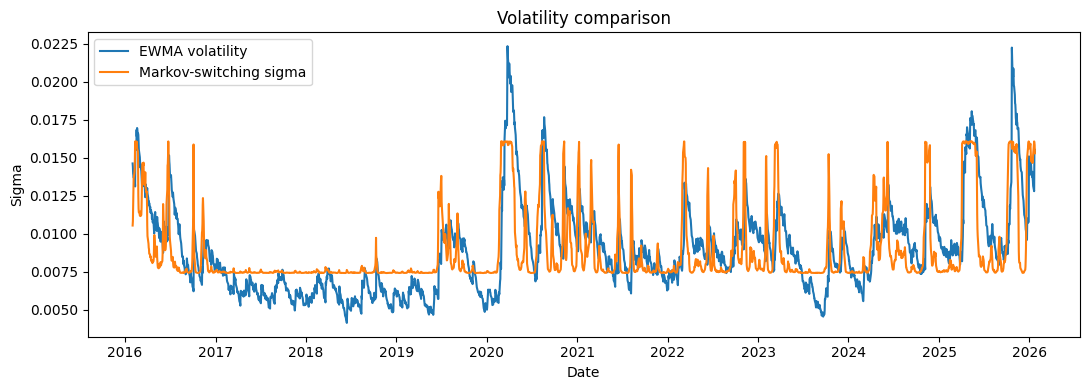

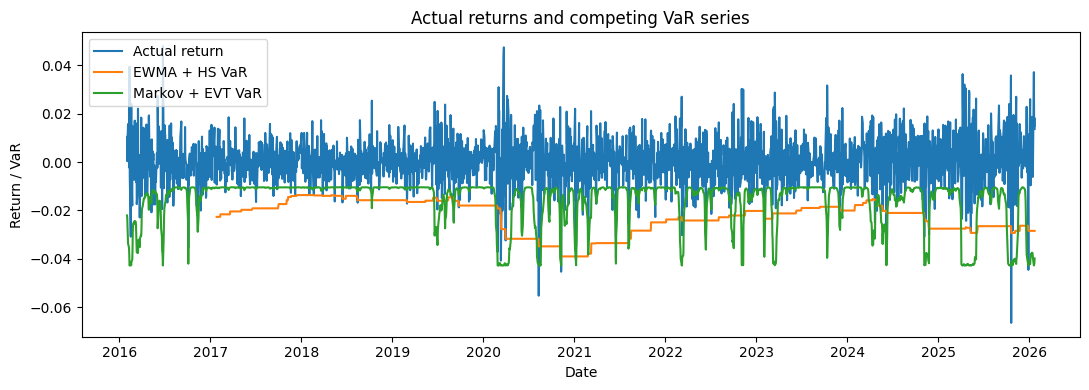

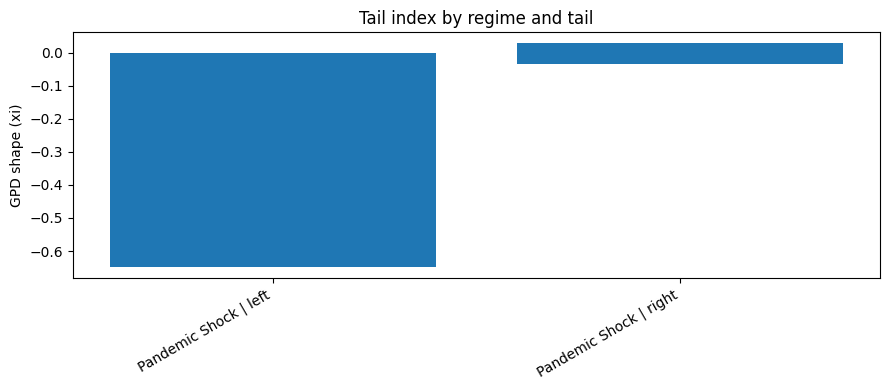

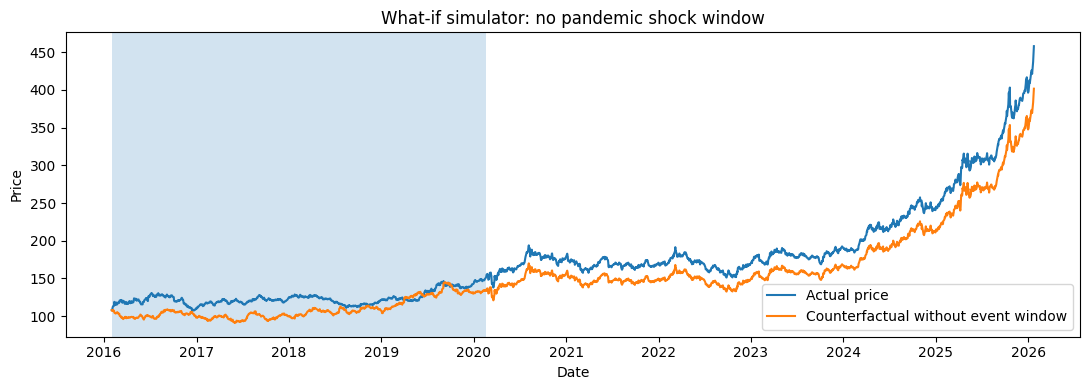

In [ ]:

fig = plt.figure(figsize=(11, 4))
plt.plot(df["Date"], df["ewma_vol"], label="EWMA volatility")
plt.plot(df["Date"], df["ms_sigma"], label="Markov-switching sigma")
plt.legend()
plt.title("Volatility comparison")
plt.xlabel("Date")
plt.ylabel("Sigma")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_volatility_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(11, 4))
plt.plot(df["Date"], df["log_return"], label="Actual return")
plt.plot(df["Date"], df["ewma_hs_var"], label="EWMA + HS VaR")
plt.plot(df["Date"], df["ms_evt_var"], label="Markov + EVT VaR")
plt.legend()
plt.title("Actual returns and competing VaR series")
plt.xlabel("Date")
plt.ylabel("Return / VaR")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_var_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(9, 4))
plt.bar(regime_tail_table["label"] + " | " + regime_tail_table["tail"], regime_tail_table["shape_xi"])
plt.xticks(rotation=30, ha='right')
plt.title("Tail index by regime and tail")
plt.ylabel("GPD shape (xi)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_tail_index_by_regime.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(11, 4))
plt.plot(counter["Date"], counter["Price"], label="Actual price")
plt.plot(counter["Date"], counter["cf_price_no_event"], label="Counterfactual without event window")
plt.axvspan(pan_start, pan_end, alpha=0.2)
plt.legend()
plt.title("What-if simulator: no pandemic shock window")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_counterfactual_no_event.png", dpi=200, bbox_inches="tight")
plt.show()


## 16. Export result files for dashboard use

In [ ]:

regime_table.to_csv(TABLE_DIR / "regime_table.csv", index=False)
regime_tail_table.to_csv(TABLE_DIR / "regime_tail_table.csv", index=False)
model_comparison.to_csv(TABLE_DIR / "model_comparison.csv", index=False)
regime_model_comparison.to_csv(TABLE_DIR / "regime_model_comparison.csv", index=False)
regime_tail_label_summary.to_csv(TABLE_DIR / "regime_tail_label_summary.csv", index=False)
tail_pivot.to_csv(TABLE_DIR / "tail_asymmetry_table.csv", index=False)
counter.to_csv(TABLE_DIR / "counterfactual_prices.csv", index=False)
df[["Date", "Price", "log_return", "ewma_vol", "ewma_hs_var", "ms_mu", "ms_sigma", "ms_evt_var", "ms_state"]].to_csv(TABLE_DIR / "timeseries_outputs.csv", index=False)

summary = {
    "price_column_used": "Price",
    "alpha": ALPHA,
    "ewma_lambda": LAMBDA,
    "break_dates": [str(d.date()) for d in break_dates],
    "pandemic_window_start": str(pan_start.date()),
    "pandemic_window_end": str(pan_end.date()),
    "best_model_by_quantile_loss": model_comparison.sort_values("quantile_loss").iloc[0]["model"],
}
with open(TABLE_DIR / "analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved files:")
for p in sorted(RESULT_DIR.rglob("*")):
    if p.is_file():
        print(p.relative_to(BASE_DIR))


Saved files:
gold_results\figures\01_price_with_breaks.png
gold_results\figures\02_returns_with_breaks.png
gold_results\figures\03_volatility_comparison.png
gold_results\figures\04_var_comparison.png
gold_results\figures\05_tail_index_by_regime.png
gold_results\figures\06_counterfactual_no_event.png
gold_results\tables\analysis_summary.json
gold_results\tables\counterfactual_prices.csv
gold_results\tables\model_comparison.csv
gold_results\tables\regime_model_comparison.csv
gold_results\tables\regime_table.csv
gold_results\tables\regime_tail_label_summary.csv
gold_results\tables\regime_tail_table.csv
gold_results\tables\tail_asymmetry_table.csv
gold_results\tables\timeseries_outputs.csv
